In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

In [2]:
df_events = pd.read_csv('events.csv')
print(df_events.head())

    event_id  user_id product_id event_type             event_timestamp
0  E00000001  U009798    P001393       cart  2025-07-08T14:28:55.893919
1  E00000002  U005881    P000669       view  2025-10-19T23:00:44.067982
2  E00000003  U006348    P001404       view  2025-05-09T07:02:42.256662
3  E00000004  U002664    P000400       cart  2025-07-19T22:47:07.019634
4  E00000005  U005776    P000392       view  2024-10-24T10:20:33.602165


In [3]:
event_counts = df_events['event_type'].value_counts()

view_count = event_counts.get('view', 0)
cart_count = event_counts.get('cart', 0)
purchase_count = event_counts.get('purchase', 0)

print(f"👀 浏览次数 (View): {view_count}")
print(f"🛒 加购次数 (Cart): {cart_count}")
print(f"💳 购买次数 (Purchase): {purchase_count}")

cart_rate = (cart_count / view_count) * 100
purchase_rate = (purchase_count / view_count) * 100

print(f"➡️ 浏览到加购的转化率: {cart_rate:.2f}%")
print(f"➡️ 浏览到购买的总转化率: {purchase_rate:.2f}%")

👀 浏览次数 (View): 56013
🛒 加购次数 (Cart): 12035
💳 购买次数 (Purchase): 4006
➡️ 浏览到加购的转化率: 21.49%
➡️ 浏览到购买的总转化率: 7.15%


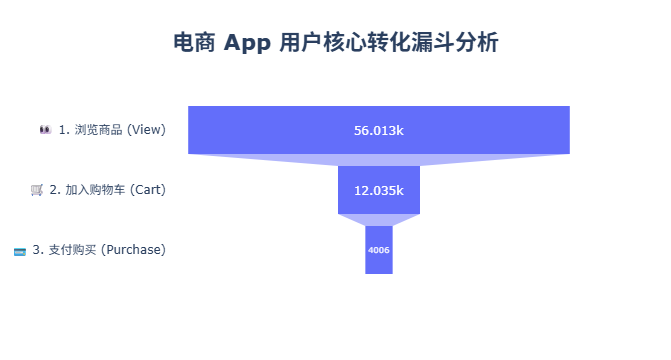

In [4]:
import plotly.express as px
import pandas as pd

stages = ['👀 1. 浏览商品 (View)', '🛒 2. 加入购物车 (Cart)', '💳 3. 支付购买 (Purchase)']
values = [view_count, cart_count, purchase_count]

df_funnel = pd.DataFrame({
    '转化环节': stages,
    '用户数量': values
})

fig = px.funnel(
    df_funnel, 
    x='用户数量', 
    y='转化环节', 
    title='<b>电商 App 用户核心转化漏斗分析</b>',
    color_discrete_sequence=['#636EFA']
)

fig.update_layout(
    title_x=0.5, 
    title_font_size=22,
    plot_bgcolor='white', 
    yaxis_title=None
)

fig.show()

In [13]:
import pandas as pd
from scipy.stats import chi2_contingency

df_events = pd.read_csv('events.csv')

user_stats = df_events.groupby('user_id')['event_type'].agg(
    has_wishlist=lambda x: 'wishlist' in x.values,
    has_purchase=lambda x: 'purchase' in x.values
).reset_index()

contingency_table = pd.crosstab(user_stats['has_wishlist'], user_stats['has_purchase'])
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("====== 观测数据特征相关性盘点 (卡方检验) ======")
print(contingency_table)
print("\n====== 统计学假设检验结果 ======")
print(f"卡方检验统计量: {chi2:.2f}")
print(f"P-Value: {p_value:.6f}")

if p_value < 0.05:
    print("\n结论：拒绝原假设。用户是否将商品加入心愿单，对其最终购买转化率有显著相关性 (置信度 > 95%)。")
else:
    print("\n结论：不能拒绝原假设。加入心愿单对购买转化率的相关性不具有统计学显著性。")

====== 观测数据特征相关性盘点 (卡方检验) ======
has_purchase  False  True 
has_wishlist              
False          3033   1458
True           3681   1823

====== 统计学假设检验结果 ======
卡方检验统计量: 0.45
P-Value: 0.500454

结论：不能拒绝原假设。加入心愿单对购买转化率的相关性不具有统计学显著性。


====== XGBoost 模型业务预测评估 ======
              precision    recall  f1-score   support

           0       0.68      0.98      0.80      1366
           1       0.26      0.02      0.04       633

    accuracy                           0.67      1999
   macro avg       0.47      0.50      0.42      1999
weighted avg       0.55      0.67      0.56      1999



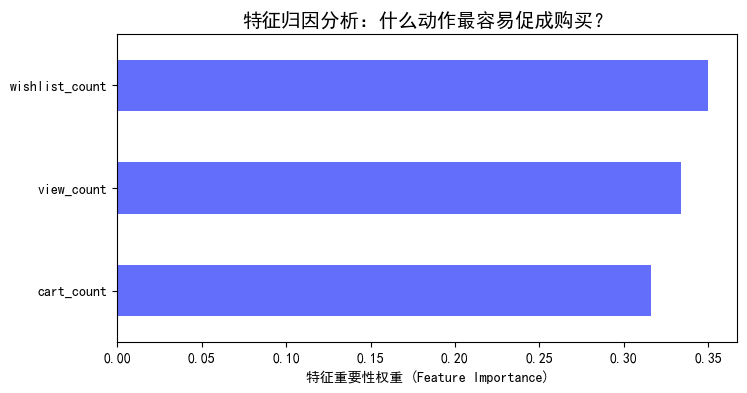

In [7]:
import pandas as pd
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei'] 
plt.rcParams['axes.unicode_minus'] = False

df_events = pd.read_csv('events.csv')

user_features = df_events.groupby('user_id').agg(
    view_count=('event_type', lambda x: (x == 'view').sum()),
    cart_count=('event_type', lambda x: (x == 'cart').sum()),
    wishlist_count=('event_type', lambda x: (x == 'wishlist').sum()),
    target_purchase=('event_type', lambda x: int('purchase' in x.values))
).reset_index()

X = user_features[['view_count', 'cart_count', 'wishlist_count']]
y = user_features['target_purchase']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

xgb_model = XGBClassifier(eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)
print("====== XGBoost 模型业务预测评估 ======")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(8, 4))
importances = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=True)
importances.plot(kind='barh', color='#636EFA')
plt.title('特征归因分析：什么动作最容易促成购买？', fontsize=14)
plt.xlabel('特征重要性权重 (Feature Importance)')
plt.show()

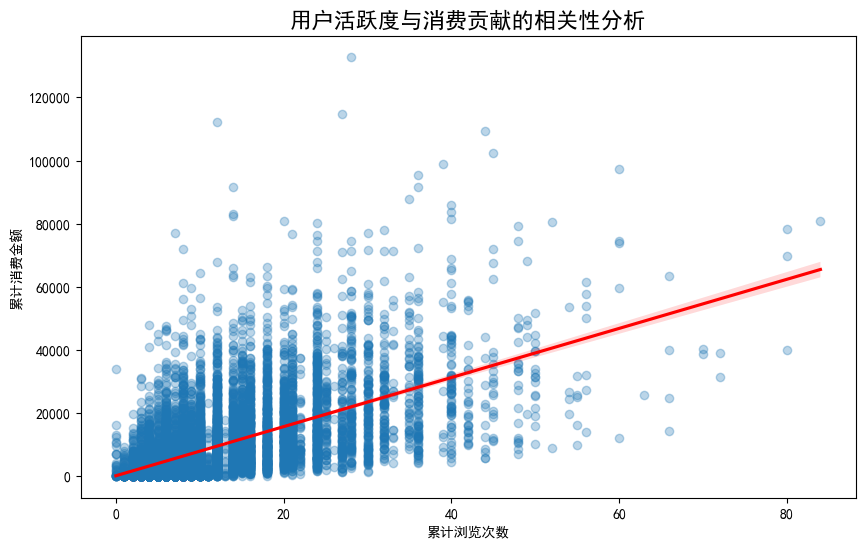

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

events = pd.read_csv('events.csv')
orders = pd.read_csv('orders.csv')
users = pd.read_csv('users.csv')

df_full = events.merge(orders, on='user_id', how='left')

user_profile = df_full.groupby('user_id').agg(
    total_views=('event_type', lambda x: (x == 'view').sum()),
    total_purchases=('event_type', lambda x: (x == 'purchase').sum()),
    total_spent=('total_amount', 'sum')
).reset_index()

plt.figure(figsize=(10, 6))
sns.regplot(data=user_profile, x='total_views', y='total_spent', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title('用户活跃度与消费贡献的相关性分析', fontsize=16)
plt.xlabel('累计浏览次数')
plt.ylabel('累计消费金额')
plt.show()